In [ ]:
# Download the FlickrLogos-27 dataset and decompress it
#######################################################

try:
    import wget
except ImportError:
    import pip
    pip.main(['install', 'wget'])
    import wget
    
import tarfile
import os

data_dir = '/workspaces/proyecto12-grupo2/data'
image_file_tar_gz = 'flickr_logos_27_dataset_images.tar.gz'
_URL = 'http://image.ntua.gr/iva/datasets/flickr_logos/flickr_logos_27_dataset.tar.gz'

if not os.path.exists(os.path.join(data_dir, 'flickr_logos_27_dataset.tar.gz')):
    print(f"Downloading original dataset in {data_dir}...")
    wget.download(_URL, out=data_dir)

    # Decompress the dataset
    print("Decompressing dataset...")
    file = tarfile.open(os.path.join(data_dir, 'flickr_logos_27_dataset.tar.gz'))
    file.extractall(data_dir)
    file.close()

    # Decompress images dataset
    print("Decompressing images...")
    file = tarfile.open(os.path.join(data_dir, 'flickr_logos_27_dataset', image_file_tar_gz))
    file.extractall(os.path.join(data_dir, 'flickr_logos_27_dataset'))
    file.close()

    print("All done!")
else:
    print("FlickrLogos-27 dataset already exists. Review the data directory.")


In [2]:
# Process the FlickrLogos-27 dataset to YOLOv5 format
#####################################################

import os
import shutil
try:
    import pandas as pd
except ImportError:
    import pip
    pip.main(['install', 'pandas'])
    import pandas as pd
import cv2
import numpy as np
try:
    from sklearn.model_selection import train_test_split
except ImportError:
    import pip
    pip.main(['install', 'scikit-learn'])
    from sklearn.model_selection import train_test_split

# --- CONFIGURATION ---
WORKING_DIR = '/workspaces/proyecto12-grupo2/data/flickr_logos_27_dataset'
BASE_IMG_DIR = 'flickr_logos_27_dataset_images'
TRAIN_ANNOT = 'flickr_logos_27_dataset_training_set_annotation.txt'
OUTPUT_BASE = 'datasets/flickr27'
# --- 1. LOAD AND CLEAN DATA ---
df_all = pd.read_csv(os.path.join(WORKING_DIR, TRAIN_ANNOT), sep=r'\s+', header=None)
# Remove duplicates (images appear in multiple subsets with the same boxes)
df_clean = df_all.drop_duplicates(subset=[0, 1, 3, 4, 5, 6]).copy()
brand_classes = sorted(df_clean[1].unique().tolist())
class_map = {name: i for i, name in enumerate(brand_classes)}
# --- 2. TRAIN/VAL SPLIT (80/20) ---
unique_filenames = df_clean[0].unique()
train_imgs, val_imgs = train_test_split(unique_filenames, test_size=0.2, random_state=42)
def process_split(filenames, split_name):
    img_out = os.path.join(WORKING_DIR, OUTPUT_BASE, 'images', split_name)
    lbl_out = os.path.join(WORKING_DIR, OUTPUT_BASE, 'labels', split_name)
    os.makedirs(img_out, exist_ok=True)
    os.makedirs(lbl_out, exist_ok=True)
    for img_name in filenames:
        src_path = os.path.join(WORKING_DIR, BASE_IMG_DIR, img_name)
        img = cv2.imread(src_path)
        if img is None: continue
        h, w = img.shape[:2]
        img_boxes = df_clean[df_clean[0] == img_name]
        label_path = os.path.join(lbl_out, img_name.rsplit('.', 1)[0] + ".txt")
        
        with open(label_path, 'w') as f:
            for _, row in img_boxes.iterrows():
                brand = row[1]
                x1, y1, x2, y2 = float(row[3]), float(row[4]), float(row[5]), float(row[6])
                # Normalize to YOLO format
                f.write(f"{class_map[brand]} {((x1+x2)/2)/w:.6f} {((y1+y2)/2)/h:.6f} {(x2-x1)/w:.6f} {(y2-y1)/h:.6f}\n")
        shutil.copy2(src_path, os.path.join(img_out, img_name))
# --- 3. EXECUTE & YAML ---
process_split(train_imgs, 'train')
process_split(val_imgs, 'val')
with open(os.path.join(WORKING_DIR, OUTPUT_BASE, 'flickr27.yaml'), 'w') as f:
    f.write(f"path: {os.path.join(WORKING_DIR, OUTPUT_BASE)}\ntrain: images/train\nval: images/val\nnames:\n")
    for i, name in enumerate(brand_classes): f.write(f"  {i}: {name}\n")
print("Done! Dataset is cleanly converted and split.")

Done! Dataset is cleanly converted and split.


In [7]:
# Train the model
#################
from ultralytics import YOLO

import os

label_path = 'datasets/flickr27/labels/val'
files = os.listdir(os.path.join(WORKING_DIR, label_path))
if len(files) == 0:
    print("ERROR: The validation labels folder is empty!")
else:
    with open(os.path.join(os.path.join(WORKING_DIR, label_path), files[0]), 'r') as f:
        print(f"Example label ({files[0]}):")
        print(f.read())

# LOAD MODEL: Load the YOLO11 model weights (choices: nano, small, medium, large, extra large) for training.
model = YOLO('yolo11m.pt') 

# TRAINAL: Begin training using the dataset configuration file (flickr27.yaml) generated in the previous step.
results = model.train(
    workers=8,
    data=os.path.join(WORKING_DIR, OUTPUT_BASE, 'flickr27.yaml'),
    epochs=100,
    imgsz=640,
    batch=8,
    # --- ENHANCED TRAINING HYPERPARAMETERS ---
    close_mosaic=20,    # CLOSE MOSAIC: Disable mosaic augmentation in the final 20 epochs to stabilize training and refine final accuracy.
    label_smoothing=0.1,# LABEL SMOOTHING: Prevents the model from becoming over-confident on potentially noisy labels by smoothing the target distribution.
    cls=2.0,            # CLASS LOSS WEIGHT: Increases the importance of the classification loss relative to the box loss.
    # --- ADVANCED IMAGE AUGMENTATION ---
    degrees=15.0,       # ROTATION: Randomly rotate images up to 15 degrees to improve robustness to orientation.
    shear=5.0,          # SHEAR: Apply shearing transformations to simulate different camera angles and perspectives.
    perspective=0.001,  # PERSPECTIVE: Apply perspective transformations to help the model learn 3D logo viewpoints.
    flipud=0.5,         # VERTICAL FLIP: Apply vertical flips with a 50% chance to help the model generalize logo shapes.
    # --- PATH AND OUTPUT SETTINGS ---
    project='/workspaces/proyecto12-grupo2/models', 
    name='models_org',
    # -----------------------
    exist_ok=True, # OVERWRITE: If the target output directory already exists, overwrite it instead of creating a new incremented directory.
    save=True
)

Example label (3521287781.txt):
19 0.273000 0.516176 0.166000 0.244118

WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.8 🚀 Python-3.11.14 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 7940MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=20, cls=2.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/workspaces/proyecto12-grupo2/data/flickr_logos_27_dataset/datasets/flickr27/flickr27.yaml, degrees=15.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01


image 1/1 /workspaces/proyecto12-grupo2/data/flickr_logos_27_dataset/datasets/flickr27/images/val/3369741917.jpg: 640x640 1 BMW, 46.8ms
Speed: 1.5ms preprocess, 46.8ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /workspaces/proyecto12-grupo2/data/flickr_logos_27_dataset/datasets/flickr27/images/val/4750267378.jpg: 480x640 1 Sprite, 21.8ms
Speed: 1.2ms preprocess, 21.8ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /workspaces/proyecto12-grupo2/data/flickr_logos_27_dataset/datasets/flickr27/images/val/1107796028.jpg: 640x512 1 Citroen, 141.4ms
Speed: 1.1ms preprocess, 141.4ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 512)

image 1/1 /workspaces/proyecto12-grupo2/data/flickr_logos_27_dataset/datasets/flickr27/images/val/132888485.jpg: 640x640 1 Cocacola, 33.3ms
Speed: 1.3ms preprocess, 33.3ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)


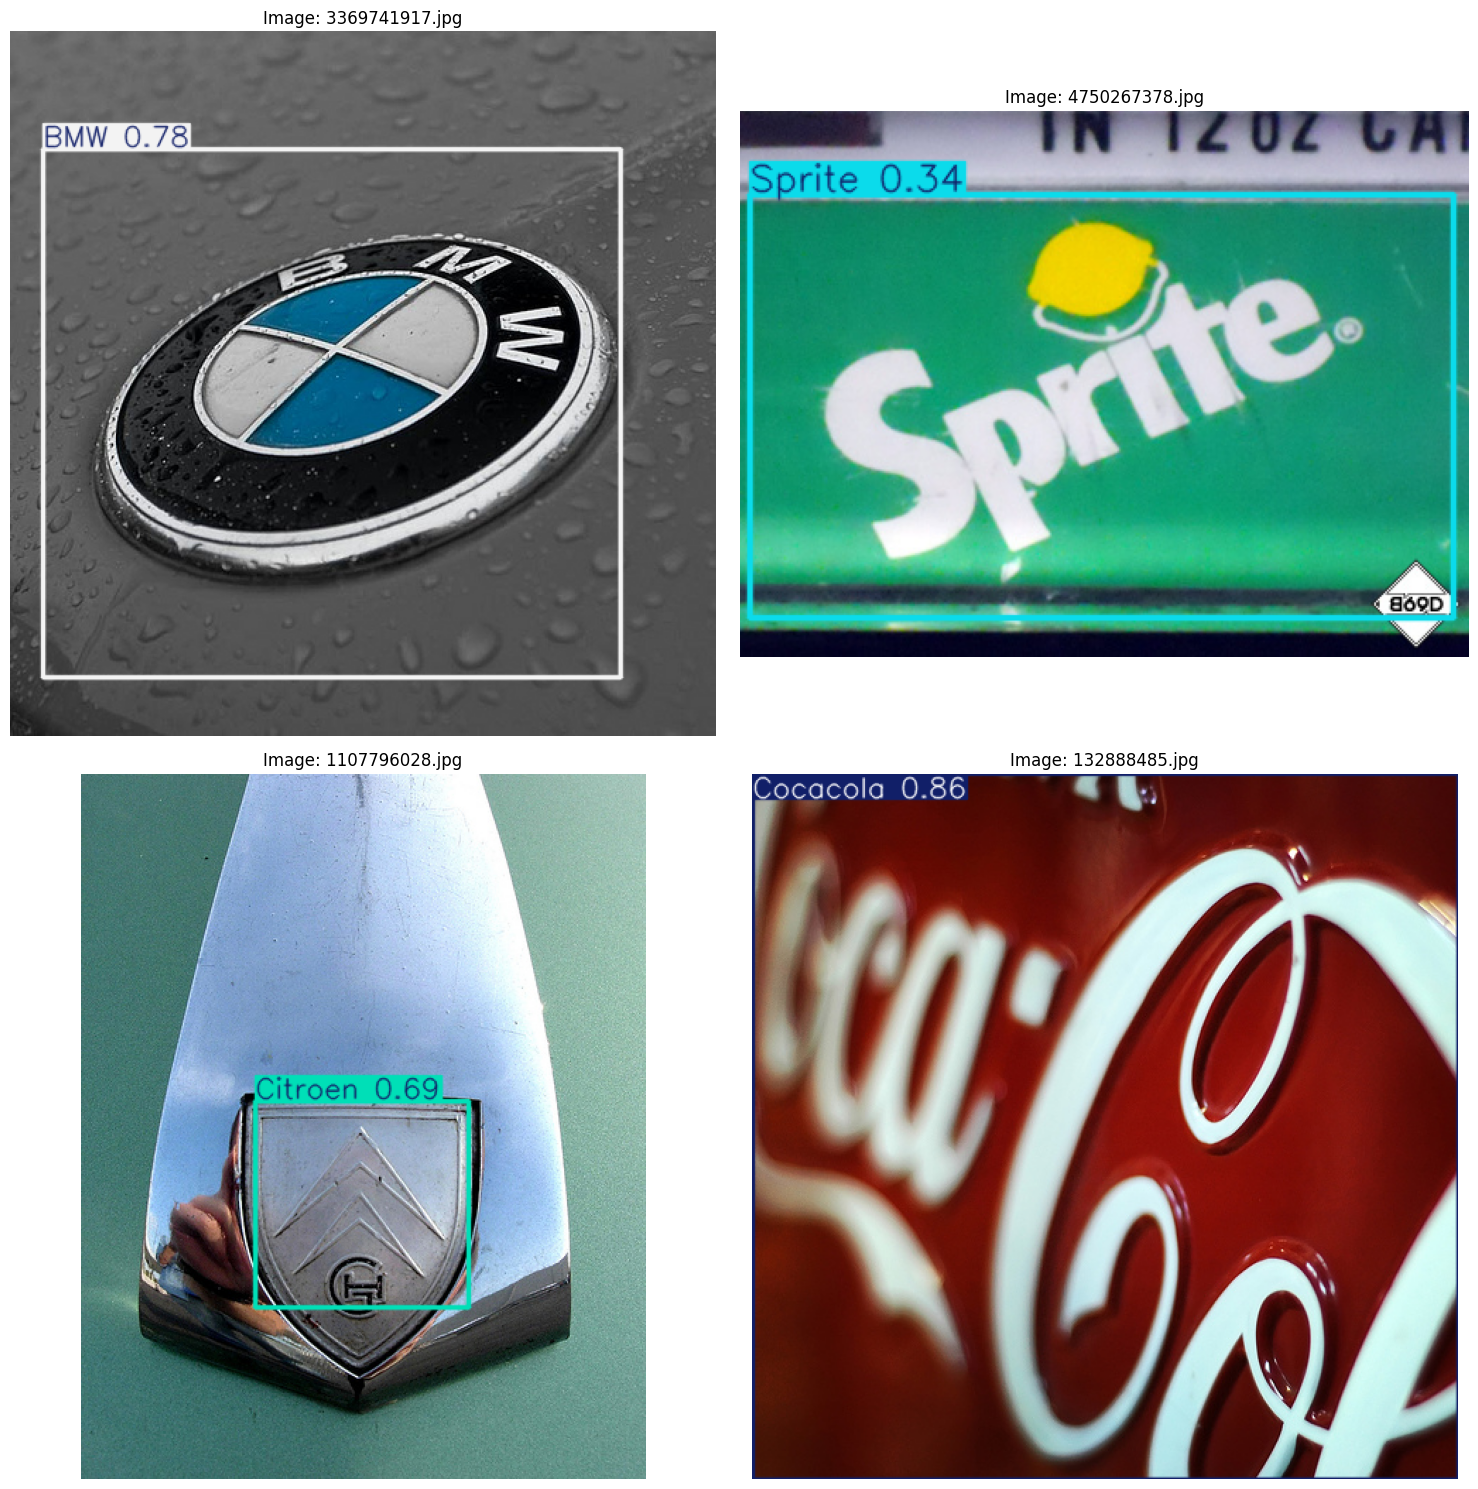

In [6]:
# Test the model with dataset images
####################################
%matplotlib inline
import os
import random
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. LOAD BEST MODEL: Load the best weights obtained during the previous training session (weights/best.pt).
model = YOLO('/workspaces/proyecto12-grupo2/models/models_org/weights/best.pt')

# 2. CONFIGURE PATHS: Set up the base paths for validation images and other necessary data.
val_images_path = os.path.join(WORKING_DIR, OUTPUT_BASE, 'images', 'val')
all_val_images = [os.path.join(val_images_path, f) for f in os.listdir(val_images_path) if f.endswith(('.jpg', '.png'))]

# 3. RANDOM SELECTION: Pick 4 images at random from the validation set to visualize model performance.
sample_images = random.sample(all_val_images, 4)

# 4. CREATE VISUALIZATION: Set up a 2x2 grid using Matplotlib to display the detection results.
fig, axs = plt.subplots(2, 2, figsize=(15, 15))
axs = axs.flatten()

for i, img_path in enumerate(sample_images):
    results = model(img_path, conf=0.25) # CONFIDENCE THRESHOLD: Use a 0.25 confidence threshold for object detection.
    res_plotted = results[0].plot()
    
    axs[i].imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
    axs[i].set_title(f"Image: {os.path.basename(img_path)}")
    axs[i].axis('off')

plt.tight_layout()
plt.show()




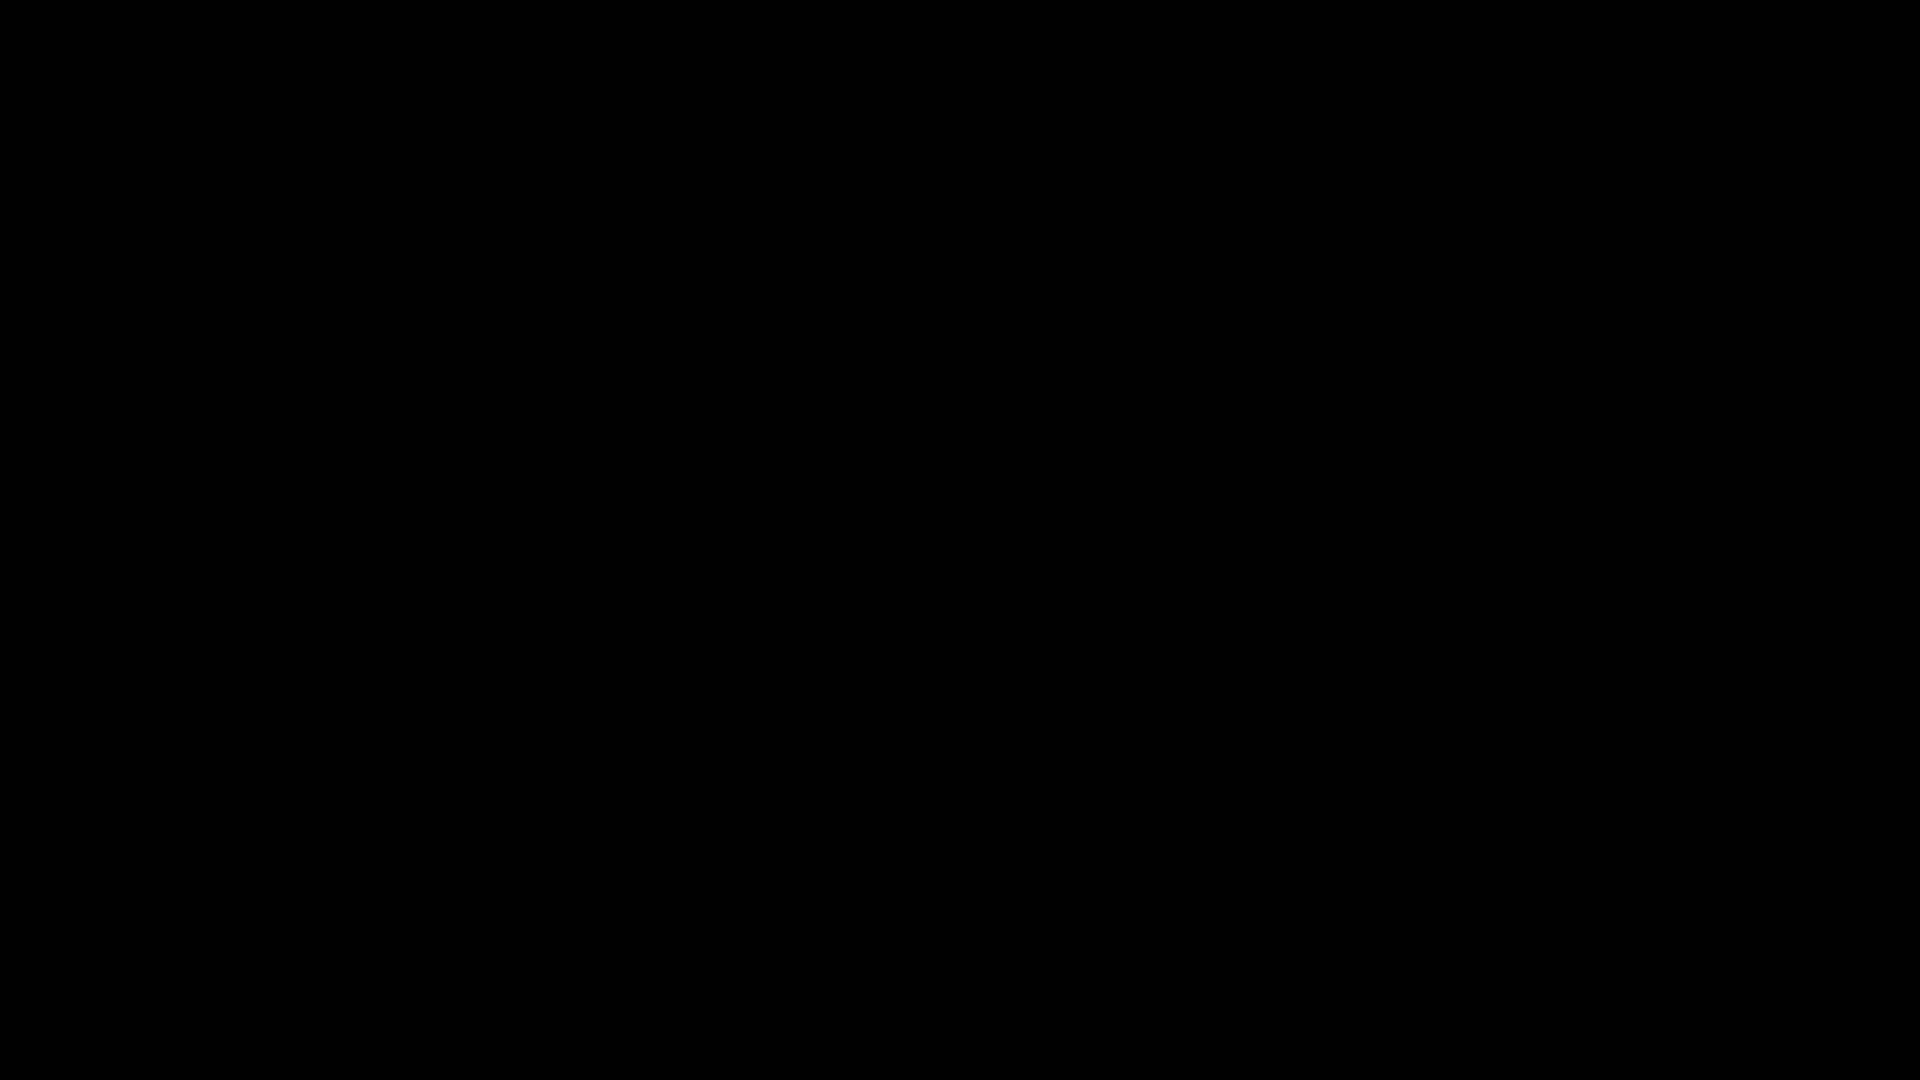

Speed: 2.1ms preprocess, 18.8ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)


In [ ]:
# Test with video
#################
from ultralytics import YOLO
import cv2
from IPython.display import display, Image, clear_output

model = YOLO('/workspaces/proyecto12-grupo2/models/models_org/weights/best.pt')
source_url = 'https://www.youtube.com/watch?v=-_-oi1Apm8I'

results = model.predict(source=source_url, conf=0.45, stream=True)

for r in results:
    annotated_frame = r.plot()
    
    # Encode the frame as a JPEG to display it in the notebook
    _, buffer = cv2.imencode('.jpg', annotated_frame)
    
    # Clear the previous frame and show the new one
    clear_output(wait=True)
    display(Image(data=buffer))